In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df = pd.read_excel("Hockey.xlsx")
df.head(10)

,ID,NAME,LOCATION,DEPT,AGE
0,A002,BHAVESH BALDANIYA,Delhi,technology,35
1,A003,YASH BAVISHI,Delhi,production,22
2,A004,SHREEKARA BHAT,Indore,sales,34
3,A005,KUNAL BHATT,Mumbai,technology,31
4,A013,ANIKET GAMI,Indore,production,42
5,A014,RAHUL GIMHAVANEKAR,Delhi,production,27
6,A016,YOSUFF HUSSAIN,Pune,sales,29
7,A018,ISHWAR IYER,Delhi,production,29
8,A019,ATHARVA KADAM,Indore,marketing,28
9,A021,KARAN KAMAT,Pune,technology,44


In [40]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['ID', 'NAME', 'LOCATION', 'DEPT'], dtype='object')

In [37]:
df['hocke_sloc'] = df['LOCATION']+df['DEPT']
df

,ID,NAME,LOCATION,DEPT,AGE,hocke_sloc
0,A002,BHAVESH BALDANIYA,Delhi,technology,35,Delhitechnology
1,A003,YASH BAVISHI,Delhi,production,22,Delhiproduction
2,A004,SHREEKARA BHAT,Indore,sales,34,Indoresales
3,A005,KUNAL BHATT,Mumbai,technology,31,Mumbaitechnology
4,A013,ANIKET GAMI,Indore,production,42,Indoreproduction
5,A014,RAHUL GIMHAVANEKAR,Delhi,production,27,Delhiproduction
6,A016,YOSUFF HUSSAIN,Pune,sales,29,Punesales
7,A018,ISHWAR IYER,Delhi,production,29,Delhiproduction
8,A019,ATHARVA KADAM,Indore,marketing,28,Indoremarketing
9,A021,KARAN KAMAT,Pune,technology,44,Punetechnology


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [35]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


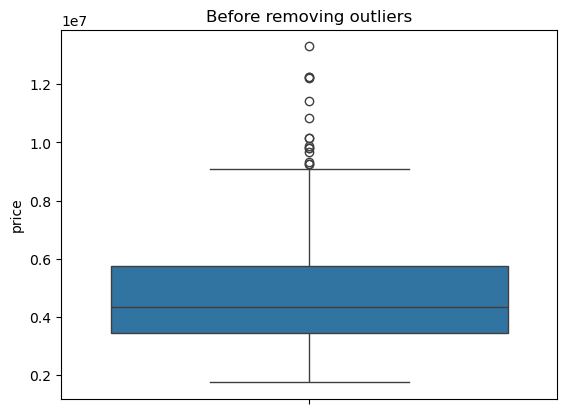

In [36]:
sns.boxplot(df['price'])
plt.title('Before removing outliers')
plt.show()

as we can see outliers above the max whisker


In [37]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = 0.75 - 0.25

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

no_outliers = df[(df['price']>= lower_bound) & (df['price']<=upper_bound)]

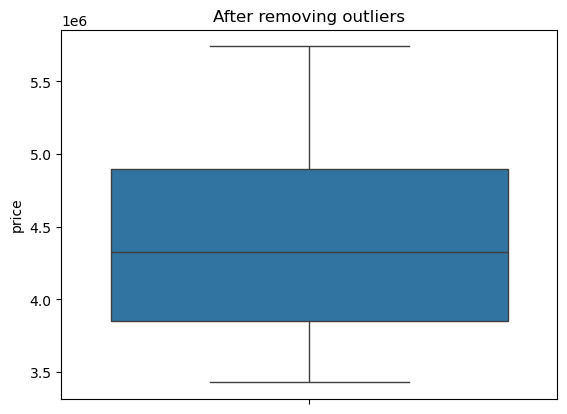

In [38]:
sns.boxplot(no_outliers['price'])
plt.title('After removing outliers')
plt.show()

In [39]:
# 📦 Outlier Detection (IQR) - Numerical Columns
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"{col} outliers count: {outliers.shape[0]}")

price outliers count: 15
area outliers count: 12
bedrooms outliers count: 12
bathrooms outliers count: 1
stories outliers count: 41
parking outliers count: 12


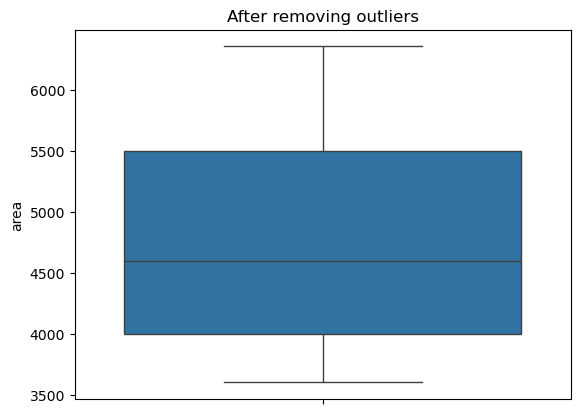

In [40]:
# for removing outliers 
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = 0.75 - 0.25

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

no_area_outliers = df[(df['area']>= lower_bound) & (df['area']<=upper_bound)]
sns.boxplot(no_area_outliers['area'])
plt.title('After removing outliers')
plt.show()

In [42]:
# feature creation

df['total_rooms'] = df['bedrooms']+df['bathrooms']
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,6
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,8
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,5
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,6
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished,3
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished,4
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished,3
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished,4


In [43]:
#group bys

print(df.groupby('furnishingstatus')['price'].mean())



furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64


In [44]:
# 📦 Pivot Table
pivot = pd.pivot_table(df, values='price', index='furnishingstatus', columns='mainroad', aggfunc='mean')
print(pivot)

mainroad                    no           yes
furnishingstatus                            
furnished         3.412111e+06  5.638843e+06
semi-furnished    3.796247e+06  5.083288e+06
unfurnished       3.062784e+06  4.263397e+06


In [47]:
from sklearn.preprocessing import StandardScaler
# 📦 Standardisation
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 📦 Encoding Categorical Columns
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


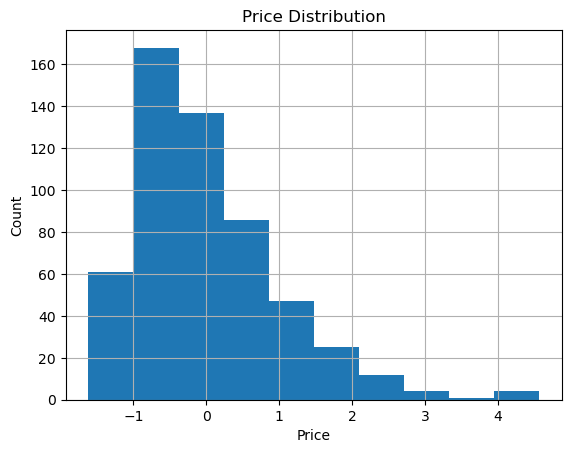

In [49]:
# 📦 Histogram
df['price'].hist(bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


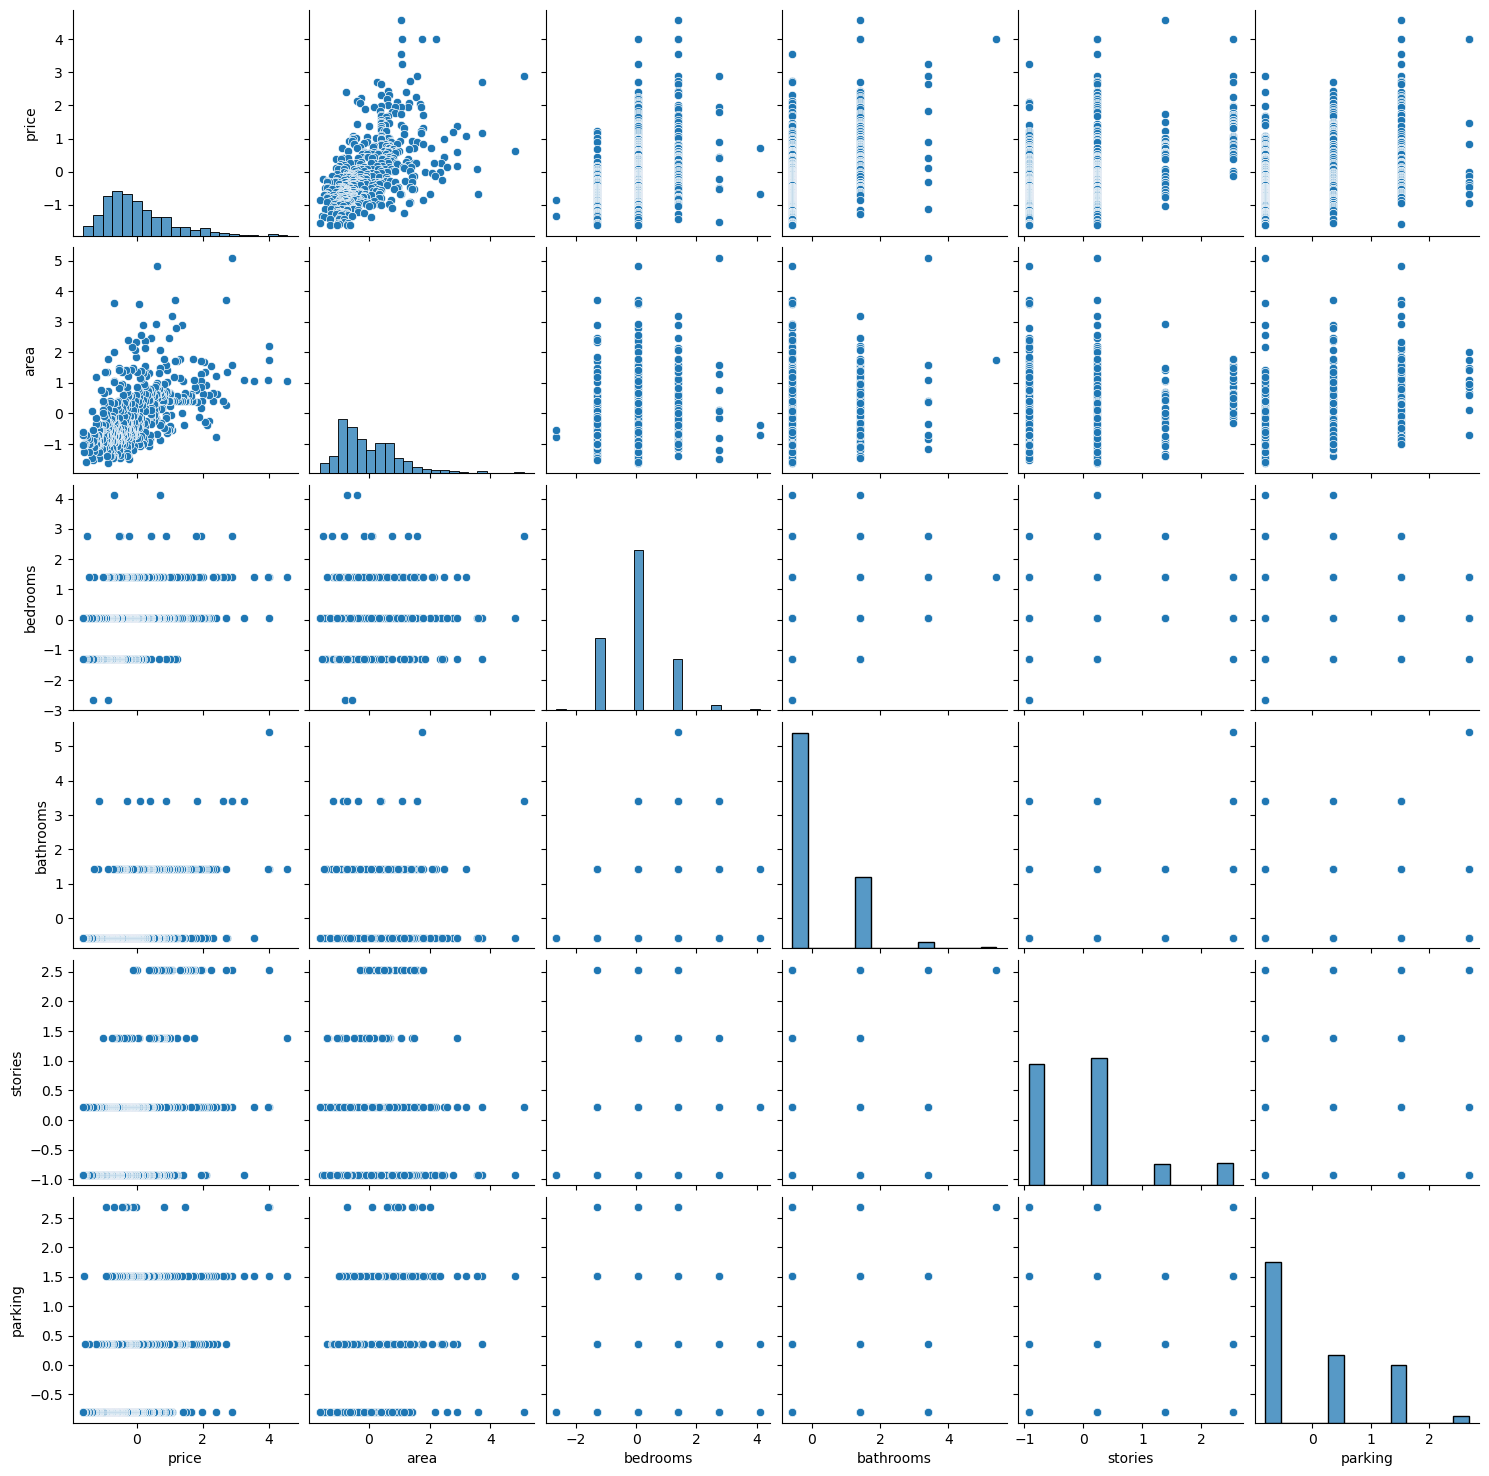

In [50]:
sns.pairplot(df, vars=['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'])
plt.show()

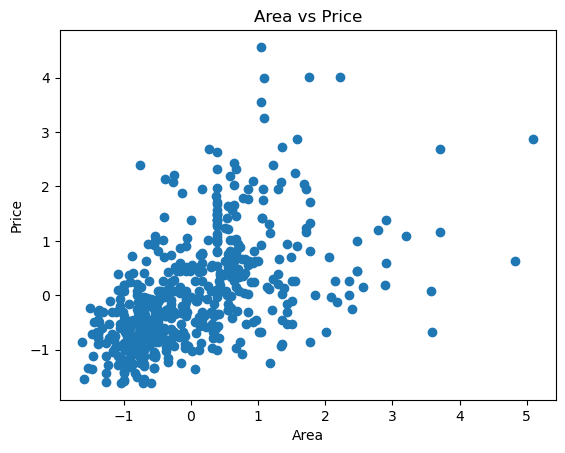

In [51]:
plt.scatter(df['area'], df['price'])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()


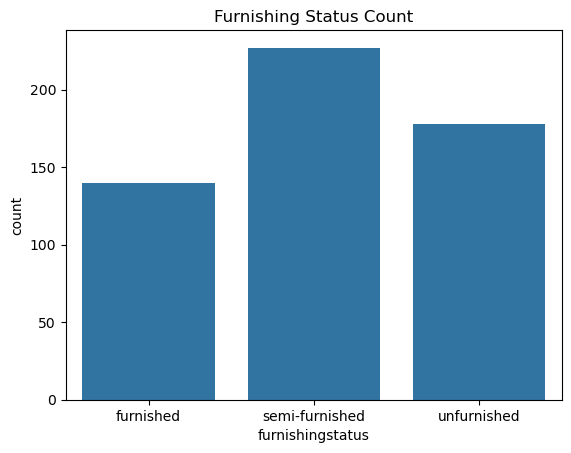

In [52]:
sns.countplot(x='furnishingstatus', data=df)
plt.title("Furnishing Status Count")
plt.show()

In [59]:
#titanic dataset using seaborn

def tit_sur():
    titanic = sns.load_dataset("titanic")
    survival_by_gender = titanic.groupby('sex')['survived'].mean()*100

    print(f"Male survival rate: {survival_by_gender['male']:.2f}%")
    print(f"Female survival rate: {survival_by_gender['female']:.2f}%")

    return survival_by_gender
tit_sur()

Male survival rate: 18.89%
Female survival rate: 74.20%


sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

In [60]:
import sqlite3

def create_sqlite_database():
    # Connect to SQLite database (creates a new database if it doesn't exist)
    conn = sqlite3.connect('example.db')
    
    # Create a cursor
    cursor = conn.cursor()
    
    # Execute a query to get SQLite version
    cursor.execute('SELECT SQLITE_VERSION()')
    
    # Fetch the result
    version = cursor.fetchone()
    
    print(f"SQLite Database created successfully. Version: {version[0]}")
    
    # Create a sample table
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS employees (
        id INTEGER PRIMARY KEY,
        name TEXT NOT NULL,
        department TEXT NOT NULL,
        salary REAL
    )
    ''')
    
    # Commit changes and close the connection
    conn.commit()
    conn.close()
    
    return version[0]

create_sqlite_database()

SQLite Database created successfully. Version: 3.46.0


'3.46.0'

In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [11]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='tip', ylabel='total_bill'>

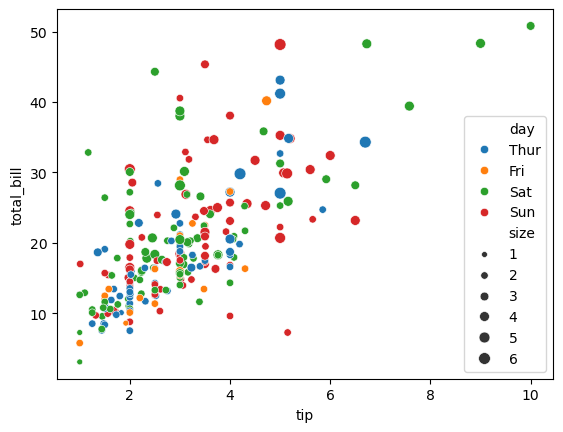

In [13]:
sns.scatterplot(x = "tip", y="total_bill", data=tips, hue="day", size = "size")

<Axes: xlabel='tip', ylabel='Count'>

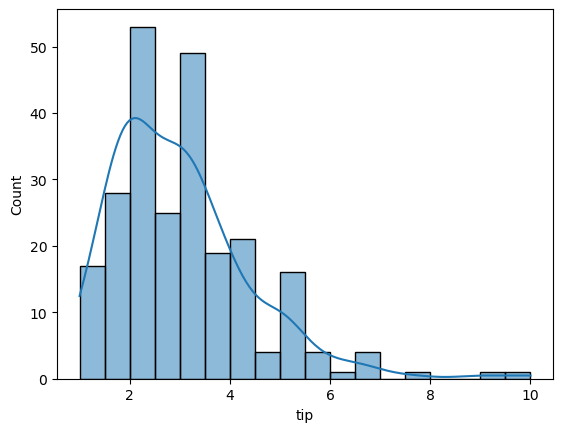

In [14]:
sns.histplot(tips['tip'], kde=True)

<Axes: xlabel='sex', ylabel='tip'>

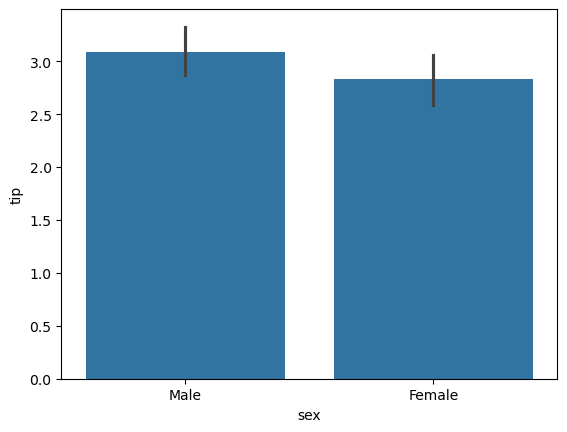

In [15]:
sns.barplot(x = "sex", y = "tip", data=tips)

In [17]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [18]:
df['Amount'] = df['Quantity']*df['UnitPrice']

In [19]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60


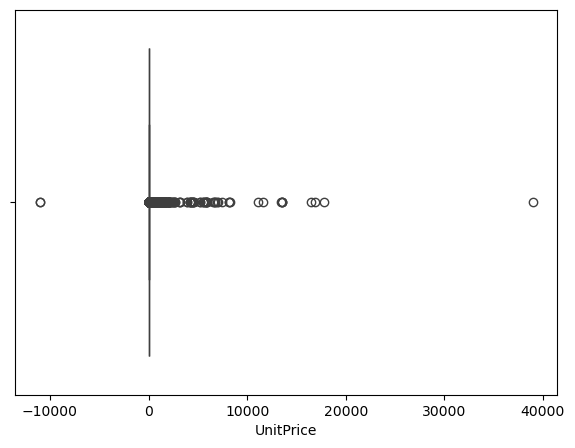

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(x=df['UnitPrice'])
plt.show()

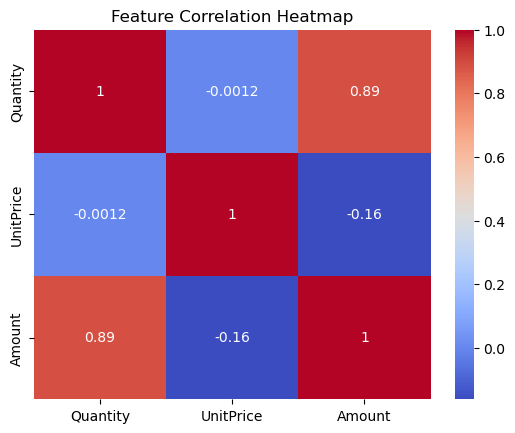

In [23]:
corr = df[['Quantity', 'UnitPrice', 'Amount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

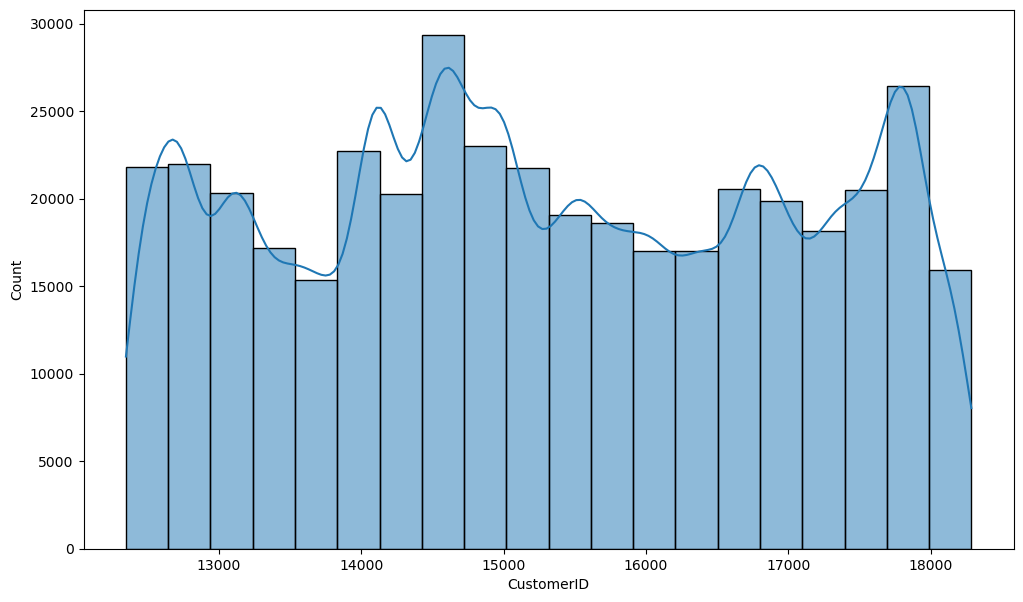

In [27]:
plt.figure(figsize=(12,7))
sns.histplot(df['CustomerID'], kde=True, bins = 20)
plt.show()

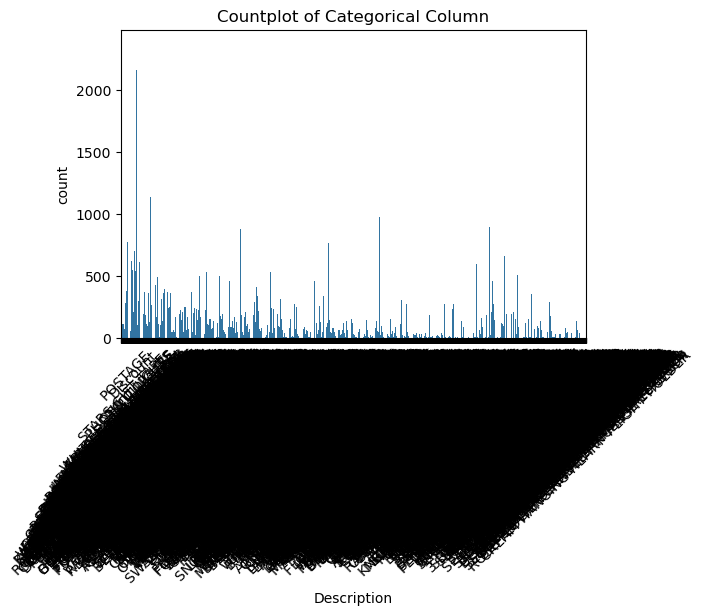

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Description'], data=df)
plt.title("Countplot of Categorical Column")
plt.xticks(rotation=45)
plt.show()

In [30]:
sns.pairplot(df, hue='CustomerID')
plt.title("Pairplot for Multivariate Analysis")
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x75bac6e24cc0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
q1 
q3 = df['Amount'].quantile(0.75)
iqr = q3-q1
lower = q1-1.5*iqr
upepr = q3+1.5*iqr

df= df[(df['num']>= lower & ](df['num'] <= upper)